In [4]:
import pandas as pd
import numpy as np
import sys
parent_path = '/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline'
sys.path.append(parent_path)
from SynOmics.metrics.fidelity.PairwiseSimilarity import PairwiseSimilarity
from SynOmics.processing.metadata import MetaData
from SynOmics.processing.postprocessing import post_masking

or_data = pd.read_csv("Integration_MelanomaData/integrated_data_melanoma.csv", index_col = 0)
clinical_cols = or_data.iloc[:,0:54].columns.tolist()
        
clinicals_or_data = or_data[clinical_cols]
ordinal_features = ["BR", "Mstage", "Tx_Start_ECOG",
                       "numPriorTherapies","biopsyContext"]
metadata_clinicals = MetaData.get_metadata(data = clinicals_or_data, 
                                 threshold_unique_values = 10, 
                                    ordinal_features = ordinal_features)

In [ ]:
from typing import Dict, Optional, Tuple
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
from scipy import stats
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl


def plot_violin_with_pvalue_heatmap(
    scores_dict: Dict[str, np.ndarray],
    title: Optional[str] = None,
    figsize: Tuple[int, int] = (14, 6),
    order: Optional[list] = None,
    palette='Set2',
    alpha: float = 0.05,
    cmap_green: str = 'Greens',
    pink_color: str = '#ffd6e0',
    white_color: Tuple[float, float, float] = (1.0, 1.0, 1.0),
    test: str = 'ranksums',
    annotate: bool = True,
    adjusted: bool = True,
    fontsize: int = 11,
):
    # Basic validation
    if not scores_dict or len(scores_dict) < 2:
        raise ValueError("scores_dict must contain at least two groups to compare.")

    methods = list(scores_dict.keys()) if order is None else order
    missing = [m for m in methods if m not in scores_dict]
    if missing:
        raise ValueError(f"The following methods specified in order are missing from scores_dict: {missing}")

    # Build DataFrame for plotting (drop NaNs)
    records = []
    for m in methods:
        arr = np.asarray(scores_dict[m])
        arr = arr[~np.isnan(arr)]
        for v in arr:
            records.append((m, float(v)))
    df = pd.DataFrame(records, columns=['method', 'score'])
    if df.empty:
        raise ValueError("After removing NaNs, no data remains to plot.")

    # Compute pairwise p-values using Wilcoxon rank-sum (ranksums)
    n = len(methods)
    pmat = pd.DataFrame(np.ones((n, n)), index=methods, columns=methods, dtype=float)
    statmat = pd.DataFrame(np.nan, index=methods, columns=methods, dtype=float)

    for i, j in itertools.combinations(range(n), 2):
        m1 = methods[i]
        m2 = methods[j]
        a = df.loc[df['method'] == m1, 'score'].values
        b = df.loc[df['method'] == m2, 'score'].values

        if len(a) < 2 or len(b) < 2:
            stat, p = np.nan, np.nan
        else:
            if test == 'ranksums':
                stat, p = stats.ranksums(a, b)
            else:
                raise ValueError("Unsupported test. Only 'ranksums' supported in this function.")
        pmat.loc[m1, m2] = pmat.loc[m2, m1] = p
        statmat.loc[m1, m2] = statmat.loc[m2, m1] = stat

    # Diagonal set to 0 for convenience (not used for significance)
    np.fill_diagonal(pmat.values, 0.0)
    np.fill_diagonal(statmat.values, 0.0)

    # If requested, adjust p-values for multiple testing (Benjamini-Hochberg FDR)
    pmat_used = pmat.copy()
    if adjusted:
        try:
            from statsmodels.stats.multitest import multipletests
        except ImportError as e:
            raise ImportError("statsmodels is required to adjust p-values. Install it (pip install statsmodels).") from e

        # collect upper triangle p-values (i < j)
        idx_pairs = []
        pvals = []
        for i in range(n):
            for j in range(i + 1, n):
                p = pmat.iat[i, j]
                if np.isnan(p):
                    p = 1.0
                pvals.append(p)
                idx_pairs.append((i, j))

        if len(pvals) > 0:
            rej, pvals_adj, _, _ = multipletests(pvals, alpha=alpha, method='fdr_bh')
            # build adjusted p-value DataFrame (symmetric)
            pmat_adj = pd.DataFrame(np.ones((n, n)), index=methods, columns=methods, dtype=float)
            for (i, j), padj in zip(idx_pairs, pvals_adj):
                pmat_adj.iat[i, j] = pmat_adj.iat[j, i] = padj
            np.fill_diagonal(pmat_adj.values, 0.0)
            pmat_used = pmat_adj
        else:
            # nothing to adjust; keep raw
            pmat_used = pmat.copy()


    eps = 1e-300
    p_clipped = pmat_used.copy().replace(0.0, np.nan)  # keep diagonal as nan for now in clipping
    p_clipped = p_clipped.fillna(1.0)
    # compute -log10(p) matrix
    with np.errstate(divide='ignore'):
        logp = -np.log10(p_clipped.clip(eps, 1.0))
    # determine scale for shading greens: compute threshold logp for alpha
    logp_threshold = -np.log10(max(alpha, eps))
    # find maximum logp among significant cells to normalize; set a lower bound
    sig_logp_vals = logp.values.flatten()
    sig_logp_vals = sig_logp_vals[~np.isnan(sig_logp_vals)]
    # only consider values > logp_threshold (i.e., p < alpha)
    sig_logp_vals = sig_logp_vals[sig_logp_vals > logp_threshold]
    if sig_logp_vals.size > 0:
        logp_max = float(np.nanmax(sig_logp_vals))
    else:
        # set a reasonable default to avoid division by zero
        logp_max = logp_threshold + 1.0

    # Prepare colormap and color constants
    cmap = cm.get_cmap(cmap_green)
    pink_rgba = mcolors.to_rgba(pink_color)
    white_rgba = mcolors.to_rgba(white_color)

    rgba_array = np.zeros((n, n, 4), dtype=float)
    for i, m1 in enumerate(methods):
        for j, m2 in enumerate(methods):
            if i == j:
                rgba_array[i, j, :] = white_rgba
                continue
            p = pmat_used.loc[m1, m2]
            if np.isnan(p) or p >= alpha:
                rgba_array[i, j, :] = pink_rgba
            else:
                # significant: compute normalized intensity between 0 and 1
                val = -np.log10(max(p, eps))
                # map val from [logp_threshold, logp_max] -> [0,1]
                if logp_max - logp_threshold <= 0:
                    norm = 1.0
                else:
                    norm = (val - logp_threshold) / (logp_max - logp_threshold)
                    norm = np.clip(norm, 0.0, 1.0)
                # use cmap to get green shade; shift to use darker colors for higher norm
                rgba = cmap(0.2 + 0.8 * norm)  # avoid the very lightest greens (start at 0.2)
                rgba_array[i, j, :] = rgba

    # Plotting
    sns.set(style="whitegrid", rc={'axes.facecolor': (0.98, 0.98, 0.99)})
    pal = palette if (isinstance(palette, (list, tuple)) and len(palette) >= n) else sns.color_palette(palette, n_colors=n)

    fig = plt.figure(figsize=figsize)
    # Create gridspec with two panels: violin (left, larger) and heatmap (right)
    gs = fig.add_gridspec(nrows=1, ncols=10, width_ratios=[6, 0.2, 3, 0.2, 0.8, 0.0, 0.0, 0.0, 0.0, 0.0], wspace=0.8)
    ax_violin = fig.add_subplot(gs[0, 0])
    ax_heatmap = fig.add_subplot(gs[0, 2])

    # Violin plot
    sns.violinplot(
        x='method',
        y='score',
        data=df,
        order=methods,
        palette=pal,
        cut=0,
        inner='quartile',
        linewidth=1.2,
        ax=ax_violin
    )

    # Compute and plot means
    means = df.groupby('method')['score'].mean().reindex(methods)
    ylim = ax_violin.get_ylim()
    yspan = ylim[1] - ylim[0] if (ylim[1] - ylim[0]) != 0 else 1.0
    for i, m in enumerate(methods):
        mean_val = means.loc[m]
        # white diamond with black edge
        ax_violin.scatter(i, mean_val, color='white', edgecolor='black', s=80, zorder=10, linewidth=1.1, marker='D')
        if annotate:
            ax_violin.text(i, mean_val + yspan * 0.03, f"{mean_val:.3f}",
                           ha='center', va='bottom', fontsize=fontsize - 1, color='black')

    ax_violin.set_xlabel('')
    ax_violin.set_ylabel('Score', fontsize=fontsize)
    ax_violin.tick_params(axis='x', labelsize=fontsize - 1, rotation=90)
    ax_violin.tick_params(axis='y', labelsize=fontsize - 1)
    if title:
        ax_violin.set_title(title, fontsize=fontsize + 1, fontweight='bold')
    else:
        ax_violin.set_title('Distribution of scores by method\n(mean shown as white diamond)', fontsize=fontsize + 1, fontweight='bold')
    # sns.despine(trim=True, ax=ax_violin)

    # Heatmap: display the RGBA array. We flip vertically so that first method is on top (matching DataFrame order)
    ax_heatmap.imshow(rgba_array, aspect='equal', interpolation='nearest', origin='upper')
    ax_heatmap.set_xticks(np.arange(n))
    ax_heatmap.set_yticks(np.arange(n))
    ax_heatmap.set_xticklabels(methods, rotation=45, ha='right', fontsize=fontsize - 1)
    ax_heatmap.set_yticklabels(methods, fontsize=fontsize - 1)
    ax_heatmap.set_title('Pairwise significance\n(white: diagonal, pink: n.s., green: significant)', fontsize=fontsize - 1)
    # gridlines between cells for clarity (disabled by default)
    # ax_heatmap.set_xticks(np.arange(-0.5, n, 1), minor=True)
    # ax_heatmap.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax_heatmap.grid(False)
    ax_heatmap.tick_params(which='minor', bottom=False, left=False)

    # Add colorbar that corresponds to green intensity only (i.e. -log10(p) for significant cells).
    # Build a ScalarMappable that maps [logp_threshold, logp_max] to greens colormap range [0.2..1]
    import matplotlib as mpl
    norm = mpl.colors.Normalize(vmin=logp_threshold, vmax=max(logp_threshold + 1e-6, logp_max))
    # create a new cmap that matches the segment we used (0.2..1 of the chosen cmap)
    # build a ListedColormap by sampling
    sample_vals = np.linspace(0.2, 1.0, 256)
    sampled_colors = cmap(sample_vals)
    sampled_cmap = mpl.colors.ListedColormap(sampled_colors)
    sm = mpl.cm.ScalarMappable(cmap=sampled_cmap, norm=norm)
    sm.set_array([])  # for colorbar
    cbar = fig.colorbar(sm, ax=ax_heatmap, fraction=0.046, pad=0.04)
    cbar.set_label('-log10(p) (only significant cells)', fontsize=fontsize - 1)
    # We keep colorbar ticks readable
    cbar_ticks = np.linspace(logp_threshold, max(logp_threshold, logp_max), num=4)
    cbar.set_ticks(cbar_ticks)
    cbar.set_ticklabels([f"{t:.1f}" for t in cbar_ticks])

    plt.tight_layout()
    return fig, (ax_violin, ax_heatmap), pmat_used

In [8]:
syn_df = pd.read_csv("synthesizers/gaussiancopula_42/gaussiancopula_42.csv", index_col = 0)

clinical_syn_df = syn_df[clinical_cols]
# clinical_syn_df = clinical_syn_df.drop(columns = ["Tx"])
pw_computer = PairwiseSimilarity(
        original_data = clinicals_or_data,
        synthetic_data = clinical_syn_df,
        metadata = metadata_clinicals,
        output_dir = f"PairwiseTranscriptomicsSimi/PairwiseTranscriptomicsSimi_42",
        verbose = True,
        save = True,
        name = "gaussiancopula_42"
    )
result = pw_computer.get_pairwise_scores(method = "spearman")
        # results_seed[syn_data] =result
        # correlations_scores = result["PairwiseScore"]

--- System & Process Info ---
Current Date and Time (UTC): 2025-11-21 16:00:59
Current User's Login: trinhtc
CPU Model: x86_64
Physical Cores: 32
Logical Processors: 32
Process RAM before execution: 513.90 MB

--- GPU Info ---
GPU monitoring failed. Ensure 'nvidia-ml-py' is installed and NVIDIA drivers are accessible.
Error: module 'nvidia_smi' has no attribute 'nvidia_smi_lib'

--- Function Execution ---
Processing data
Calculating correlation matrix for both original data and synthetic data. This matrix is mixed between spearman correlation and Cramér's V.

Summary of Pairwise score:
Summary of Pairwise Score Matrix:
  Number of elements: 1431
  Min value: 0.6644
  Max value: 1.0000
  Mean: 0.9614
  Median: 0.9717
  Standard deviation: 0.0409

--- Resource Usage Summary ---
Execution time: 15.571008 seconds
Process RAM after execution: 570.73 MB
Process RAM used by function: 56.83 MB
Average per-core CPU during execution: [0.2, 0.1, 0.2, 0.1, 0.6, 0.1, 0.1, 0.0, 0.2, 100.0, 0.3, 0.1,

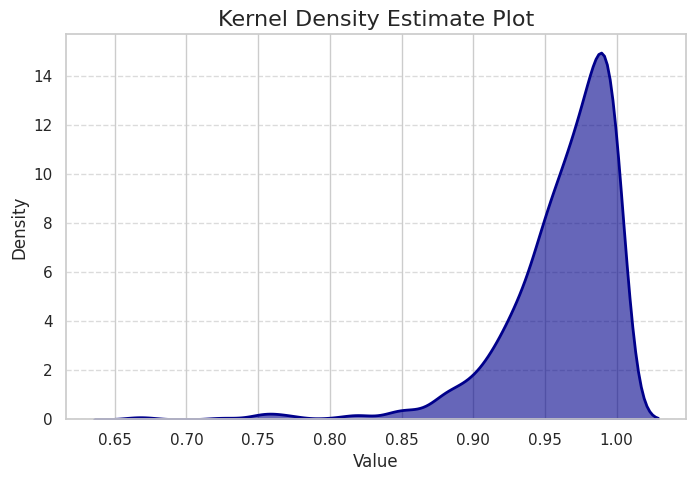

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# The 'data' variable is now a standard Python list of 500 values.

# --- 2. Generate the KDE Plot ---

plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=result["PairwiseScore"], 
    fill=True, 
    alpha=0.6,
    linewidth=2,
    color="darkblue"
)

# --- 3. Customize the Plot ---
plt.title('Kernel Density Estimate Plot', fontsize=16)
plt.xlabel('Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

In [12]:
genelist = or_data.iloc[:,55:].columns.tolist()
        
omics_or_data = or_data[genelist]

metadata_omics = MetaData.get_metadata(data = omics_or_data, 
                                 threshold_unique_values = 10, 
                                    ordinal_features = None)

In [13]:
omics_syn_df = syn_df[genelist]
# clinical_syn_df = clinical_syn_df.drop(columns = ["Tx"])
pw_computer = PairwiseSimilarity(
        original_data = omics_or_data,
        synthetic_data = omics_syn_df,
        metadata = metadata_omics,
        output_dir = f"PairwiseTranscriptomicsSimi/PairwiseTranscriptomicsSimi_42",
        verbose = True,
        save = True,
        name = "gaussiancopula_42"
    )
result = pw_computer.get_pairwise_scores(method = "spearman")

--- System & Process Info ---
Current Date and Time (UTC): 2025-11-21 16:05:08
Current User's Login: trinhtc
CPU Model: x86_64
Physical Cores: 32
Logical Processors: 32
Process RAM before execution: 607.05 MB

--- GPU Info ---
GPU monitoring failed. Ensure 'nvidia-ml-py' is installed and NVIDIA drivers are accessible.
Error: module 'nvidia_smi' has no attribute 'nvidia_smi_lib'

--- Function Execution ---
Processing data
Calculating correlation matrix for both original data and synthetic data. This matrix is mixed between spearman correlation and Cramér's V.

Summary of Pairwise score:
Summary of Pairwise Score Matrix:
  Number of elements: 175940661
  Min value: 0.5258
  Max value: 1.0000
  Mean: 0.9544
  Median: 0.9618
  Standard deviation: 0.0351

--- Resource Usage Summary ---
Execution time: 64.140064 seconds
Process RAM after execution: 4675.91 MB
Process RAM used by function: 4068.86 MB
Average per-core CPU during execution: [0.1, 0.2, 0.1, 0.0, 0.1, 0.1, 0.2, 0.1, 0.2, 100.0, 0

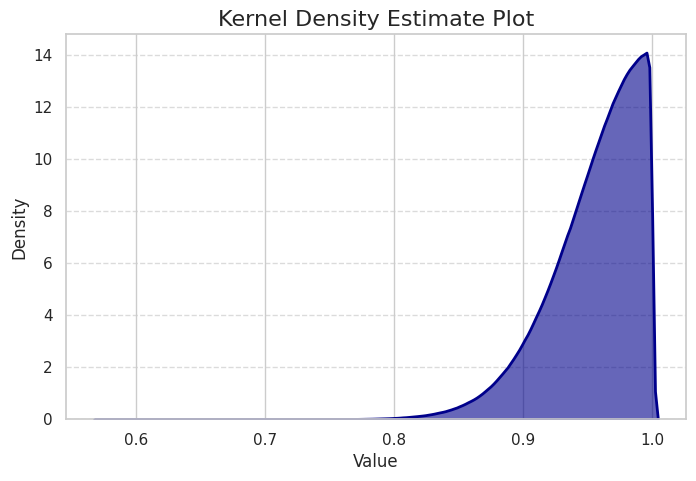

In [18]:
from numpy.random import default_rng

n = int(10e6)
rng = default_rng(42)  
pw_scores  = result["PairwiseScore"]
indices = rng.choice(pw_scores.shape[0], size=n, replace=False)
sample_scores =  pw_scores[indices]


plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=sample_scores, 
    fill=True, 
    alpha=0.6,
    linewidth=2,
    color="darkblue"
)

# --- 3. Customize the Plot ---
plt.title('Kernel Density Estimate Plot', fontsize=16)
plt.xlabel('Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

In [28]:
#Filtering
or_corr = result["OriginalCorrelation"]
filtered_indices =  np.where(np.absolute(or_corr) > 0.7)[0]
filtered_or_corr = or_corr[filtered_indices]

syn_corr = result["SyntheticCorrelation"]
filtered_syn_corr = syn_corr[filtered_indices]

scores = result["PairwiseScore"]
filtered_scores = scores[filtered_indices]

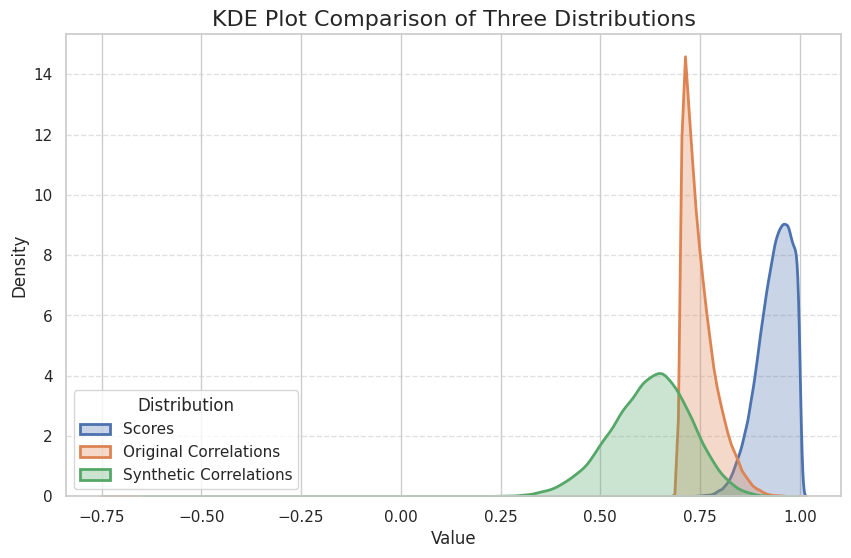

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np



# --- 2. Draw the Overlaid KDE Plots ---

plt.figure(figsize=(10, 6))

# Plot the KDE for each list
# 'label' is crucial for distinguishing the plots in the legend
sns.kdeplot(data=filtered_scores, label='Scores', fill=True, alpha=0.3, linewidth=2)
sns.kdeplot(data=filtered_or_corr, label='Original Correlations', fill=True, alpha=0.3, linewidth=2)
sns.kdeplot(data=filtered_syn_corr, label='Synthetic Correlations', fill=True, alpha=0.3, linewidth=2)

# --- 3. Customize the Plot ---
plt.title('KDE Plot Comparison of Three Distributions', fontsize=16)
plt.xlabel('Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Distribution', loc='lower left') # Add a legend
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Display the plot
# plt.savefig('three_kde_comparison.png')
plt.show()